In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from tower_eval.utils import read_lines

In [2]:
sns.set_style(
    rc={
        "patch.force_edgecolor": True,
        "patch.edgecolor": "black",
    }  # , "font": "Palatino"}
)
sns.set_style("ticks")
import matplotlib.colors as mcolors

plt.rcParams["font.family"] = "Palatino"  # change to palatino
plt.rcParams["font.size"] = 10  # change to palatino
# plt.rcParams["text.usetex"] = True
# plt.rcParams["text.latex.preamble"] = (
#     r"\RequirePackage{tgpagella} \RequirePackage{mathpazo}"
# )

In [3]:
def load_df(
    root_dir: str, context: str, model: str, lp: str, dataset: str = "wmt24_chat_dev"
):
    with open(
        f"{root_dir}/evaluations/{context}/mt/{dataset}.{lp}/vllm/{model}/evaluation.json"
    ) as f:
        data = json.load(f)
        df = pd.DataFrame()
        for col in ["chrf_segments", "comet_segments", "comet_kiwi_segments"]:
            df[col] = data[col]
    df["generations"] = read_lines(
        f"{root_dir}/generations/{context}/mt/{dataset}.{lp}/vllm/{model}/generation.txt"
    )
    raw_data = pd.read_json(
        f"{root_dir}/raw_data/mt/{dataset}.{lp}/test.jsonl", lines=True
    )
    mean_logprobs = [
        float(p)
        for p in read_lines(
            f"/mnt/data/jpombal/wmt24-chat-translation/pcxmi/{context}/mt/{dataset}.{lp}/{model}/mean_log_probs_ref.txt"
        )
    ]
    df["doc_id"] = raw_data["doc_id"]
    df["src"] = raw_data["src"]
    df["ref"] = raw_data["ref"]
    df["mean_logprob"] = mean_logprobs
    return df


class ConversationDF(pd.DataFrame):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def printc(self, id):
        convo_df = self[self["doc_id"] == id]
        for _, row in convo_df.iterrows():
            print(
                f'{row["translation_direction"]}: {row["src"]} ##(ref: {row["ref"]})##\n'
            )

In [4]:
lp = "pt-br-en"
model = "TowerInstruct-7B-w-chat-empty-sys"
root_dir = "/mnt/data/jpombal/wmt24-chat-translation"

no_context_df = load_df(root_dir, "no_context_empty_sys", model, lp)
full_context_df = load_df(root_dir, "full_context_empty_sys", model, lp)
conversational_data = ConversationDF(
    pd.read_json(
        f"{root_dir}/raw_data/mt/wmt24_chat_dev.{lp[:5]}/test.jsonl", lines=True
    )
)
conversational_data["translation_direction"] = conversational_data[
    "source_language"
].apply(lambda x: "Agent" if x == "en" else "Customer")


assert len(no_context_df) == len(full_context_df)

In [5]:
analysis_df = pd.DataFrame()
analysis_df["id"] = no_context_df["doc_id"]
analysis_df["chrf_no_context"] = no_context_df["chrf_segments"]
analysis_df["chrf_full_context"] = full_context_df["chrf_segments"]
analysis_df["comet_no_context"] = no_context_df["comet_segments"]
analysis_df["comet_full_context"] = full_context_df["comet_segments"]
analysis_df["comet_kiwi_no_context"] = no_context_df["comet_kiwi_segments"]
analysis_df["comet_kiwi_full_context"] = full_context_df["comet_kiwi_segments"]
analysis_df["chrf_dif"] = (
    full_context_df["chrf_segments"] - no_context_df["chrf_segments"]
)
analysis_df["comet_dif"] = (
    full_context_df["comet_segments"] - no_context_df["comet_segments"]
) * 100
analysis_df["comet_kiwi_dif"] = (
    full_context_df["comet_kiwi_segments"] - no_context_df["comet_kiwi_segments"]
) * 100
analysis_df["no_context_gen"] = no_context_df["generations"]
analysis_df["full_context_gen"] = full_context_df["generations"]
analysis_df["src"] = no_context_df["src"]
analysis_df["ref"] = no_context_df["ref"]
analysis_df["no_context_mean_logprob"] = no_context_df["mean_logprob"]
analysis_df["full_context_mean_logprob"] = full_context_df["mean_logprob"]
analysis_df["src_length"] = analysis_df["src"].apply(len)
analysis_df["length binned"] = pd.cut(analysis_df["src_length"], [0, 20, 50, 100, 150])
analysis_df["logprob_dif"] = (
    analysis_df["full_context_mean_logprob"] - analysis_df["no_context_mean_logprob"]
)

In [6]:
pd.set_option("display.max_rows", 2000)
pd.set_option("display.max_colwidth", None)
# analysis_df.sort_values(by="logprob_dif", ascending=False)

In [45]:
analysis_df.describe()

,chrf_no_context,chrf_full_context,comet_no_context,comet_full_context,comet_kiwi_no_context,comet_kiwi_full_context,chrf_dif,comet_dif,comet_kiwi_dif,no_context_mean_logprob,full_context_mean_logprob,src_length,logprob_dif
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,76.111611,77.613569,0.914299,0.922025,0.809967,0.810068,1.501958,0.772626,0.010135,-2.079695,-1.651138,43.327545,0.428557
std,24.102620,23.338757,0.086127,0.078779,0.077438,0.078465,15.269136,5.410315,3.769609,1.919303,1.594690,38.650979,0.531251
min,0.000000,0.000000,0.426276,0.464313,0.382975,0.376920,-82.870963,-34.694582,-34.678265,-15.072182,-13.734622,2.000000,-1.160121
25%,60.322614,63.194608,0.891560,0.903041,0.788213,0.786210,0.000000,0.000000,-0.000006,-2.509378,-1.948474,17.000000,0.134687
50%,82.264395,83.761370,0.945765,0.949951,0.842268,0.842365,0.000000,0.000000,0.000000,-1.417752,-1.080854,37.000000,0.297717
75%,100.000000,100.000000,0.971695,0.974918,0.861411,0.860379,0.875880,0.786585,0.000000,-0.927976,-0.695901,57.000000,0.562516
max,100.000000,100.000000,0.994933,0.994933,0.890228,0.890228,100.000000,40.333897,36.617422,-0.207886,-0.170409,586.000000,5.705244


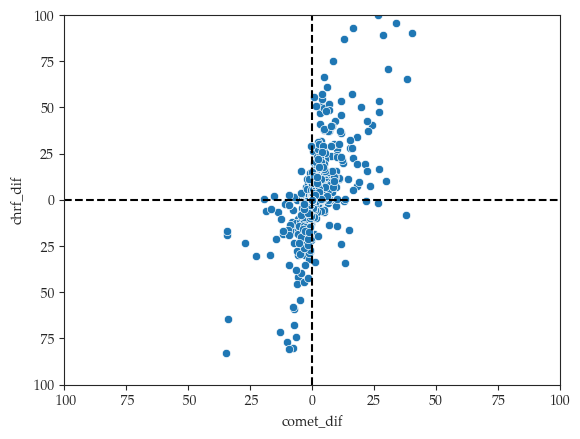

In [8]:
# scatter of chrf dif and comet dif
sns.scatterplot(data=analysis_df, x="comet_dif", y="chrf_dif")
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.hlines(0, -100, 100, linestyles="--", colors="black")
plt.vlines(0, -100, 100, linestyles="--", colors="black")
plt.show()

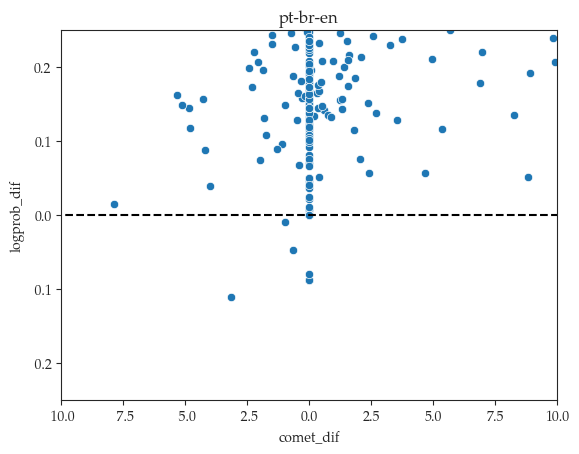

In [9]:
# scatter of chrf dif and comet dif
sns.scatterplot(
    data=analysis_df[
        analysis_df["length binned"] == analysis_df["length binned"].unique()[3]
    ],
    x="comet_dif",
    y="logprob_dif",
)
plt.xlim(-10, 10)
plt.ylim(-0.25, 0.25)
plt.hlines(0, -100, 100, linestyles="--", colors="black")
# plt.vlines(0, -100, 100, linestyles="--", colors="black")
plt.title(lp)
plt.show()

In [10]:
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_colwidth", None)
analysis_df.loc[
    :,
    [
        "id",
        "src",
        "ref",
        "no_context_gen",
        "full_context_gen",
        "comet_dif",
        "comet_kiwi_dif",
        "chrf_dif",
        "logprob_dif",
    ],
]
# [
#     analysis_df["length binned"] == analysis_df["length binned"].unique()[3]
# ]

,id,src,ref,no_context_gen,full_context_gen,comet_dif,comet_kiwi_dif,chrf_dif,logprob_dif
0,6010be8c0f6e4ae4a7af3005,Desejo cancelar a compra de um ebook,I wish to cancel the purchase of an ebook,I wish to cancel the purchase of an ebook,I wish to cancel the purchase of an ebook,-0.000012,0.000000,0.000000,0.000000
1,6010be8c0f6e4ae4a7af3005,BOa noite,Good night,Good evening.,Good evening.,0.000000,0.000000,0.000000,0.567804
2,6010be8c0f6e4ae4a7af3005,EMAIL,EMAIL,EMAIL,EMAIL,0.000000,0.000000,0.000000,0.703488
3,6010be8c0f6e4ae4a7af3005,me cadastrei hoje e comprei agora um ebook,I registered today and just bought an ebook,I signed up today and just bought an ebook.,I registered today and just bought an ebook.,2.173507,-0.225300,28.650910,0.505948
4,6010be8c0f6e4ae4a7af3005,mas nao tenho PRS-ORG e quero cancelar,But I don't have PRS-ORG and I want to cancel,but I don't have PRS-ORG and I want to cancel,But I don't have PRS-ORG and I want to cancel,1.209116,0.417149,2.992868,0.238311
...,...,...,...,...,...,...,...,...,...
1262,60162e180c2a4ffcd07c08a0,Como fazer sem ser pelo site?,How to do it without being through the website?,How to do it without being through the website?,How to do it without being through the website?,0.000000,0.000000,0.000000,0.426324
1263,60162e180c2a4ffcd07c08a0,Paguei no cartão de crédito.,I paid on credit card.,I paid with a credit card.,I paid by credit card.,1.041907,-0.192159,2.552159,0.898448
1264,60162e180c2a4ffcd07c08a0,"Se não receber o e-mail, como devo proceder?","If I don't receive the email, how should I proceed?","If I don't receive the email, what should I do?","If I don't receive the email, what should I do?",0.000000,0.000000,0.000000,0.520451
1265,60162e180c2a4ffcd07c08a0,Tem algum e-mail a qual posso me reportar?,Do you have any email I can report to?,Do you have an email I can report to?,Do you have any email I can report to?,2.022272,-0.205058,12.529485,0.423289


In [12]:
conversational_data.printc("6307e0a8613b735e130a652e")

Customer: Obrigado por entrar em contato com a Ajuda PRS-ORG, o meu nome é NAME-N. ##(ref: Thank you for contacting PRS-ORG Help, my name is NAME-N.)##

Customer: Para começar, pode-me indicar o seu nome por favor? ##(ref: To begin with, could you please tell me your name?)##

Customer: NAME-M ##(ref: NAME-M)##

Agent: Hello NAME-M! ##(ref: Olá, NAME-M.)##

Agent: Its pleasure chat with you, how are you doing today? ##(ref: É um prazer conversar com você, como você está hoje?)##

Customer: Olá, tudo bem? ##(ref: Hello, how are you?)##

Customer: Gostaria de ajuda sobre o dme do PRS-ORG ##(ref: I would like help with PRS-ORG dme)##

Customer: Eu comecei a fazer o dme mas ele pede cartas que estão fora de packs e extintas no mercado ##(ref: I started to make the dme but it asks for cards that are out of packs and extinct on the market)##

Agent: You are an incredible human! ##(ref: Você é um humano incrível!)##

Agent: Thank you so much for asking. ##(ref: Muito obrigado por perguntar.)#

In [7]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
id = "6307e0a8613b735e130a652e"
analysis_df[analysis_df["id"] == id].loc[
    :, ["src", "ref", "no_context_gen", "full_context_gen"]
]

,src,ref,no_context_gen,full_context_gen
1091,"Obrigado por entrar em contato com a Ajuda PRS-ORG, o meu nome é NAME-N.","Thank you for contacting PRS-ORG Help, my name is NAME-N.","Thank you for contacting PRS-ORG Help, my name is NAME-N.","Thank you for contacting PRS-ORG Help, my name is NAME-N."
1092,"Para começar, pode-me indicar o seu nome por favor?","To begin with, could you please tell me your name?","To begin with, could you please tell me your name?","To begin with, could you please tell me your name?"
1093,NAME-M,NAME-M,NAME-M,NAME-M
1094,"Olá, tudo bem?","Hello, how are you?","Hello, how are you?","Hello, how are you?"
1095,Gostaria de ajuda sobre o dme do PRS-ORG,I would like help with PRS-ORG dme,I would like help with the PRS-ORG dme,I would like help with the PRS-ORG dme
1096,Eu comecei a fazer o dme mas ele pede cartas que estão fora de packs e extintas no mercado,I started to make the dme but it asks for cards that are out of packs and extinct on the market,I started to do the dme but it asks for cards that are out of packs and extinct in the market,I started doing the dme but it asks for cards that are out of packs and extinct in the market
1097,Eu ja fiz 13 partes do dme e agora não consigo fazer o resto,I already did 13 parts of the dme and now I can't do the rest,I have already done 13 parts of the dme and now I can't do the rest,I have already done 13 parts of the dme and now I can't do the rest
1098,Não acho justo com os jogadores manter um dme tão caro que seja impossível de fazer,I don't think it is fair to the players to keep such an expensive dme that it is impossible to do,I don't think it's fair to the players to keep such an expensive engine that is impossible to make,I don't think it's fair to players to keep a dme so expensive that it's impossible to do
1099,"Gostaria de receber os jogadores de volta ou receber os que faltam, no caso capitaes do PRS-ORG",I would like to retrieve the players or receive the missing ones in the case of PRS-ORG captains.,"I would like to receive the players back or receive the ones that are missing, in the case of captains of PRS-ORG","I would like to get the players back or receive the ones that are missing, in this case PRS-ORG captains"
1100,Desafio de montagem de elencos,Squad Building Challenge,Casting Challenge,Squad Building Challenge
